## Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the effect of different learning rates and the number of epochs on model performance. 

### Import Library

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

### load dataset

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


### Train-test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Feature scaling 

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Create model function

In [5]:
def build_model(lr):

    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    optimizer = Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### Train with Different LR

In [6]:
learning_rates = [0.1, 0.01, 0.001]

histories = {}

for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    model = build_model(lr)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print("Test Accuracy:", accuracy)

    histories[lr] = history


Training with Learning Rate = 0.1


d:\Third Year\DL\Assignments\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 1.0

Training with Learning Rate = 0.01
Test Accuracy: 1.0

Training with Learning Rate = 0.001
Test Accuracy: 0.8333333134651184


### Compare LR

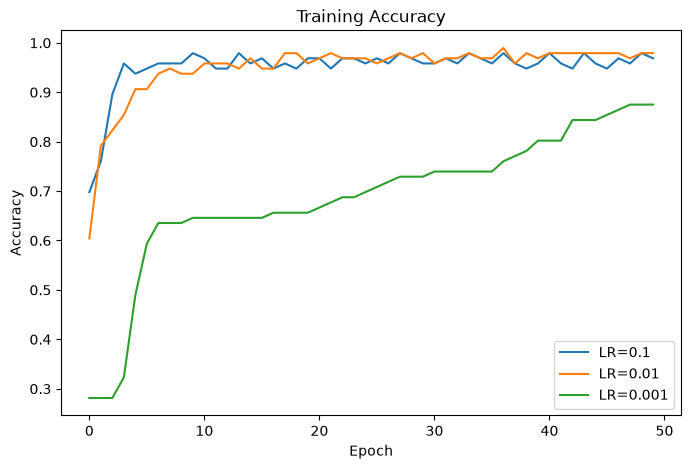

In [7]:
plt.figure(figsize=(8,5))

for lr in learning_rates:
    plt.plot(histories[lr].history['accuracy'], label=f'LR={lr}')

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Train Different Epoch

In [8]:
epochs_list = [20, 50, 100]

results = {}

for epochs in epochs_list:

    print(f"\nTraining for {epochs} epochs")

    model = build_model(0.001)

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print("Accuracy:", accuracy)

    results[epochs] = accuracy


Training for 20 epochs
Accuracy: 0.9333333373069763

Training for 50 epochs
Accuracy: 0.9666666388511658

Training for 100 epochs
Accuracy: 0.9666666388511658


### Epoch Comparsion

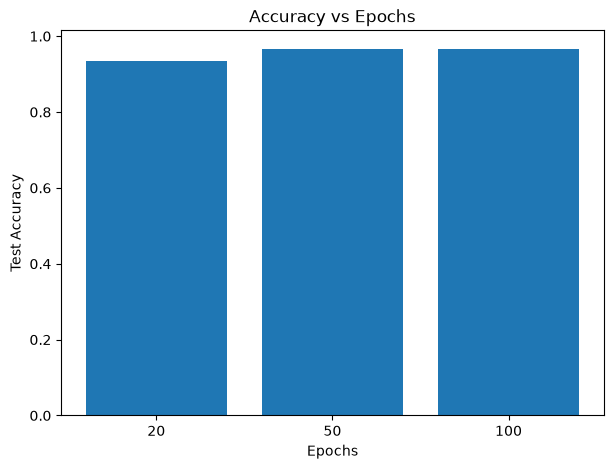

In [9]:
plt.figure(figsize=(7,5))

plt.bar(
    [str(i) for i in epochs_list],
    list(results.values())
)

plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epochs")

plt.show()

### Final Model

In [10]:
model = build_model(0.001)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5833 - loss: 0.9953 - val_accuracy: 0.6667 - val_loss: 0.9389
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 0.9293 - val_accuracy: 0.7500 - val_loss: 0.8967
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 0.8821 - val_accuracy: 0.7500 - val_loss: 0.8572
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6875 - loss: 0.8348 - val_accuracy: 0.7500 - val_loss: 0.8223
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6771 - loss: 0.7955 - val_accuracy: 0.7500 - val_loss: 0.7882
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.7637 - val_accuracy: 0.7500 - val_loss: 0.7572
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6458 - loss: 0.7330 - val_accuracy: 0.7917 - val_loss: 0.7290
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6458 - loss: 0.7049 - val_accuracy: 0.7500 - val_loss:

### Evaluate 

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0993
Loss : 0.09927663952112198
Accuracy : 1.0


### Prediction

In [12]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


### Confusion Matrix

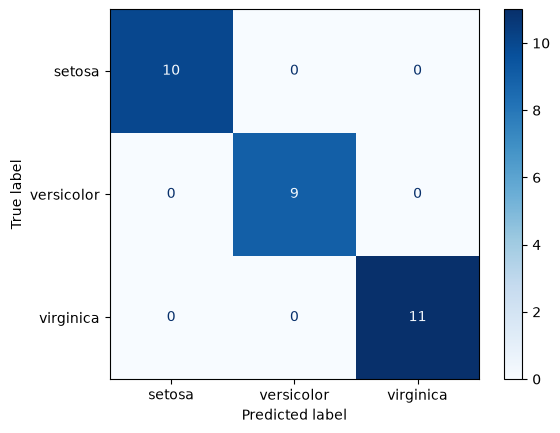

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap='Blues')

plt.show()

### Loss Curve

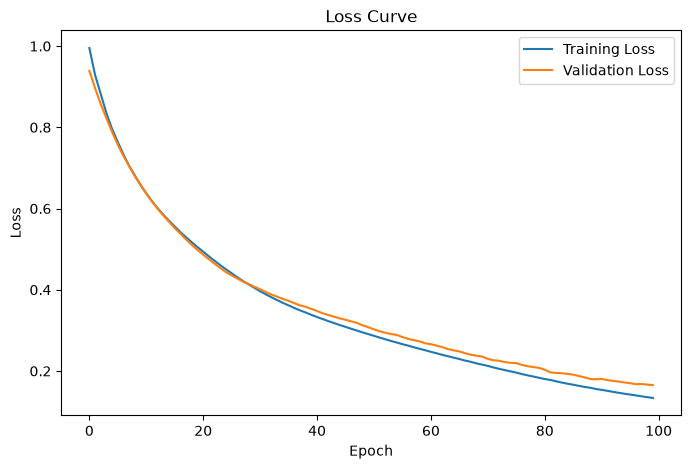

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Accuracy Curve

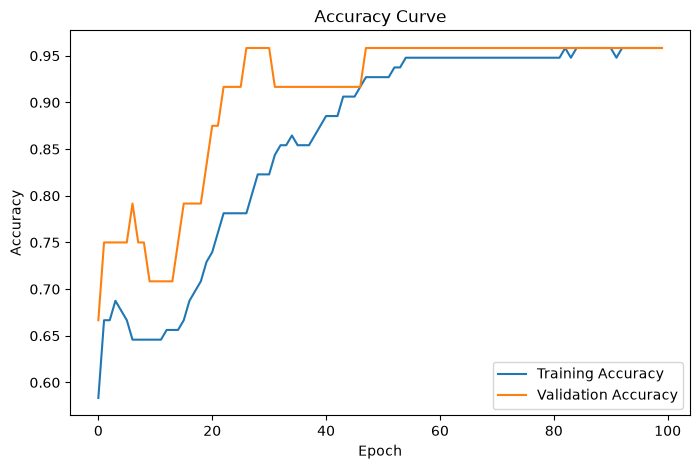

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()